In [2]:
import os

In [3]:
os.getcwd()

'/home/jingqi/RNALocateV3.0/Codes/Prediction/Validation'

In [6]:
os.chdir('/home/jingqi/RNALocateV3.0/Data/')

In [8]:
import random
import textwrap

num_sequences = 200
min_len = 500
max_len = 8000
line_width = 60
filename = "Raw/pseudo_fasta.txt"

with open(filename, "w") as f:
    for i in range(num_sequences):
        # Calculate evenly distributed length across the 200 sequences
        seq_len = int(min_len + i * (max_len - min_len) / (num_sequences - 1))
        
        # Generate random ATCG sequence
        sequence = ''.join(random.choices(['A', 'T', 'C', 'G'], k=seq_len))
        
        # Write standard FASTA header
        f.write(f">pseudo_seq_{i+1}_len_{seq_len}\n")
        
        # Write sequence broken into 60-character width lines
        for chunk in textwrap.wrap(sequence, line_width):
            f.write(chunk + "\n")

### Check the impact of pure length

Pearson Correlation between Length and Prediction Probabilities:
mitochondrion_prob            0.499461
cytoplasm_prob                0.469224
nucleus_prob                  0.438468
cytosol_prob                  0.436060
ribosome_prob                 0.420222
nucleolus_prob                0.390897
membrane_prob                 0.361041
nucleoplasm_prob              0.333310
chromatin_prob                0.270578
endoplasmic reticulum_prob    0.118758
extracellular region_prob     0.112983
Name: length, dtype: float64


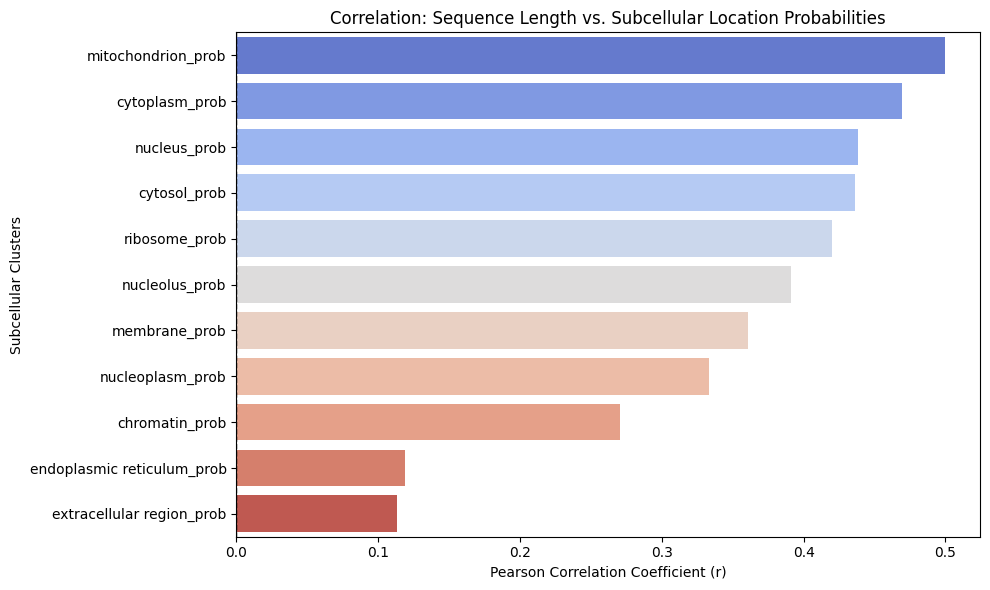

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the prediction data
df = pd.read_csv('Main/Prediciton_pseudolength.csv')

# Extract sequence length from the 'sequence_id' column 
# (Matches the digits after '_len_')
df['length'] = df['sequence_id'].str.extract(r'_len_(\d+)').astype(float)

# Isolate the columns representing cluster probabilities
prob_cols = [col for col in df.columns if col.endswith('_prob')]

# Calculate the Pearson correlation matrix for length and probabilities
correlation_matrix = df[['length'] + prob_cols].corr(method='pearson')

# Extract and sort just the correlations with 'length'
length_corr = correlation_matrix.loc['length', prob_cols].sort_values(ascending=False)

print("Pearson Correlation between Length and Prediction Probabilities:")
print(length_corr)

# Visualize the correlation distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=length_corr.values, y=length_corr.index, hue=length_corr.index, palette='coolwarm', legend=False)
plt.title('Correlation: Sequence Length vs. Subcellular Location Probabilities')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Subcellular Clusters')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

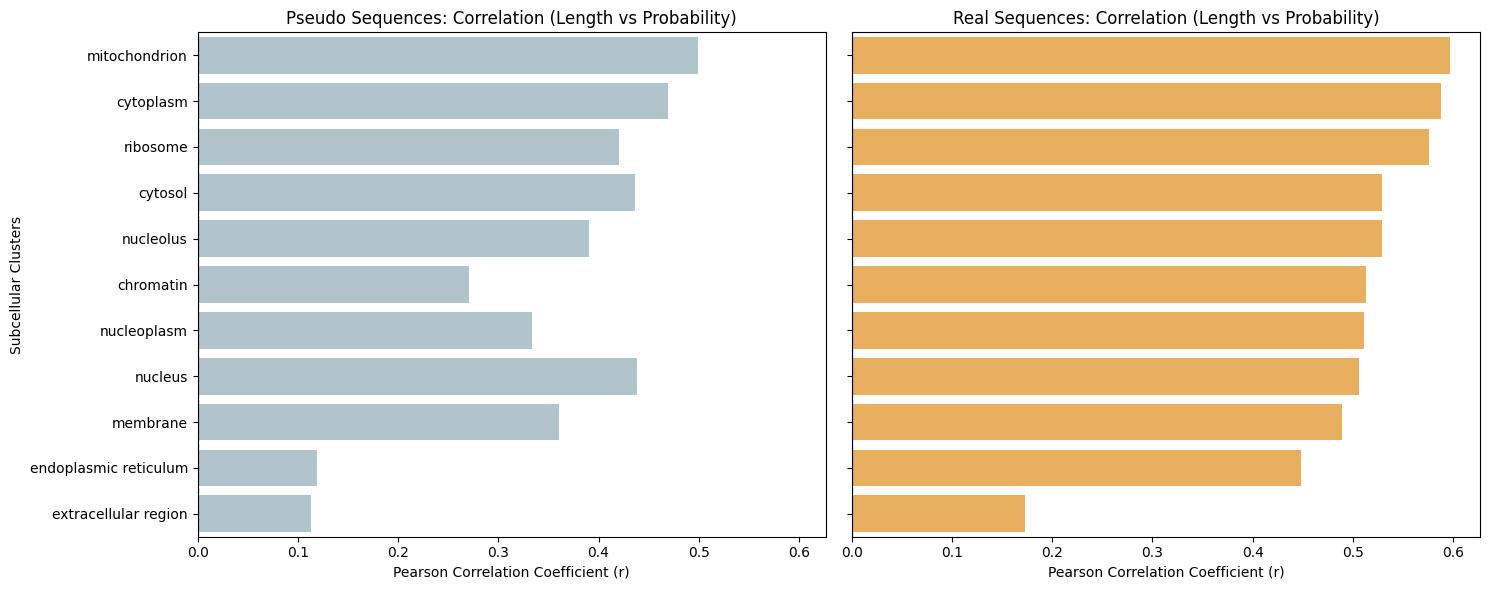

In [10]:
# Construct the dataset directly from the provided raw numbers
data = {
    'Location': [
        'mitochondrion', 'cytoplasm', 'nucleus', 'cytosol', 'ribosome',
        'nucleolus', 'membrane', 'nucleoplasm', 'chromatin', 
        'endoplasmic reticulum', 'extracellular region'
    ],
    'Pseudo_Corr': [
        0.499461, 0.469224, 0.438468, 0.436060, 0.420222, 
        0.390897, 0.361041, 0.333310, 0.270578, 0.118758, 0.112983
    ],
    'Real_Corr': [
        0.597, 0.588, 0.506, 0.529, 0.576, 
        0.529, 0.489, 0.511, 0.513, 0.448, 0.173
    ]
}

df = pd.DataFrame(data)

# Sort the entire DataFrame based on the Real correlation values in descending order
df = df.sort_values(by='Real_Corr', ascending=False).reset_index(drop=True)

# Construct the side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Left Subplot: Pseudo Data
sns.barplot(x='Pseudo_Corr', y='Location', data=df, ax=axes[0], color='#AEC6CF')
axes[0].set_title('Pseudo Sequences: Correlation (Length vs Probability)')
axes[0].set_xlabel('Pearson Correlation Coefficient (r)')
axes[0].set_ylabel('Subcellular Clusters')
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Right Subplot: Real Data
sns.barplot(x='Real_Corr', y='Location', data=df, ax=axes[1], color='#FFB347')
axes[1].set_title('Real Sequences: Correlation (Length vs Probability)')
axes[1].set_xlabel('Pearson Correlation Coefficient (r)')
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Ensure the x-axis scales are comparable (optional but recommended for visual parity)
max_xlim = max(df['Pseudo_Corr'].max(), df['Real_Corr'].max()) * 1.05
axes[0].set_xlim(0, max_xlim)
axes[1].set_xlim(0, max_xlim)

plt.tight_layout()
plt.show()

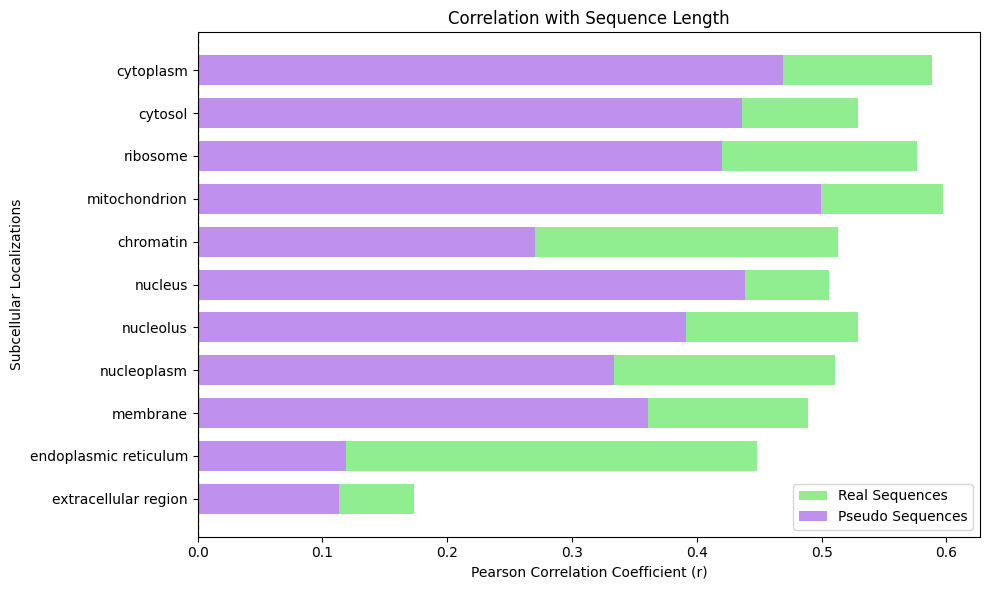

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Construct the dataset directly from the provided raw numbers
data = {
    'Location': [
        'mitochondrion', 'cytoplasm', 'nucleus', 'cytosol', 'ribosome',
        'nucleolus', 'membrane', 'nucleoplasm', 'chromatin', 
        'endoplasmic reticulum', 'extracellular region'
    ],
    'Pseudo_Corr': [
        0.499461, 0.469224, 0.438468, 0.436060, 0.420222, 
        0.390897, 0.361041, 0.333310, 0.270578, 0.118758, 0.112983
    ],
    'Real_Corr': [
        0.597, 0.588, 0.506, 0.529, 0.576, 
        0.529, 0.489, 0.511, 0.513, 0.448, 0.173
    ]
}

df = pd.DataFrame(data)

# Define the exact custom order for the y-axis (top to bottom)
custom_order = [
    'cytoplasm', 'cytosol', 'ribosome', 'mitochondrion',
    'chromatin', 'nucleus', 'nucleolus', 'nucleoplasm', 'membrane',
    'endoplasmic reticulum', 'extracellular region'
]

# Reverse the order for Matplotlib so 'cytoplasm' renders at the top of the plot
df['Location'] = pd.Categorical(df['Location'], categories=custom_order[::-1], ordered=True)
df = df.sort_values(by='Location').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Define the y-axis positions
y_positions = np.arange(len(df))

# Enforce identical width (bar height) for both datasets
bar_thickness = 0.7

# Plot Real sequences first (Background - Light Green)
ax.barh(y_positions, df['Real_Corr'], height=bar_thickness, color='#90EE90', label='Real Sequences')

# Plot Pseudo sequences second (Foreground - Light Blue, drawn directly on top)
ax.barh(y_positions, df['Pseudo_Corr'], height=bar_thickness, color='#bf90ee', label='Pseudo Sequences')

# Axis formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(df['Location'])
ax.set_xlabel('Pearson Correlation Coefficient (r)')
ax.set_ylabel('Subcellular Localizations')
ax.set_title('Correlation with Sequence Length')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Add legend to clarify the layers
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()